In [69]:
%load_ext autoreload
%autoreload 2

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

from display_functions import display_slice
from processing_functions import add_salt_and_pepper_noise, add_gaussian_noise

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# DICOM attributes
pixelSpacing = 0.703 # mm (for both x and y)
sliceSpacing = 0.625 # mm (spacing in z)
path = "c"

# I. Slicing

Final Volume Shape (x, y, z): (512, 512, 237)


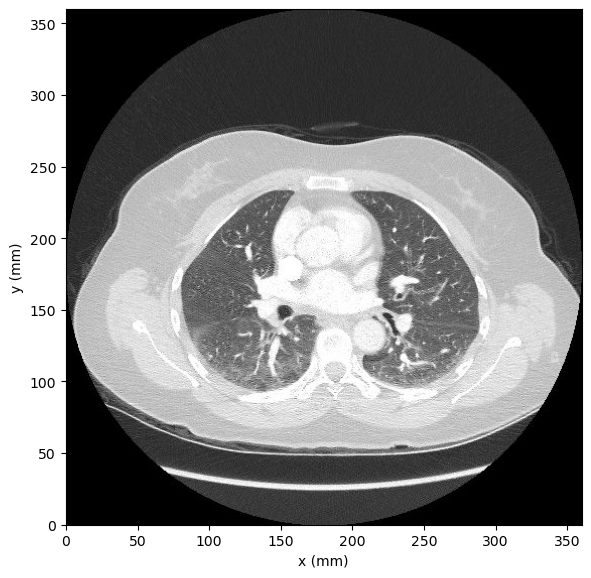

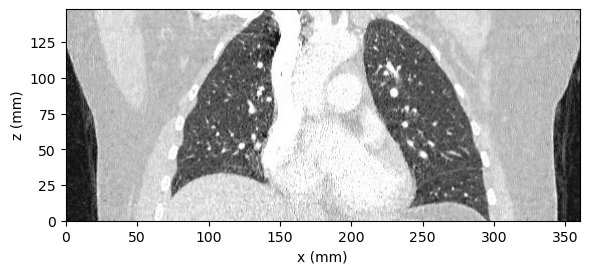

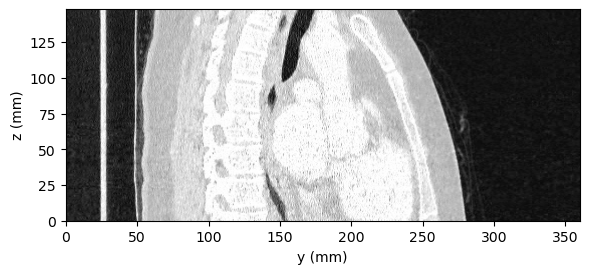

In [71]:
files = sorted([f for f in os.listdir(path) if f.endswith('.jpg')])
num_slices = len(files)

slices = [cv2.imread(os.path.join(path, f), cv2.IMREAD_GRAYSCALE) for f in files]
volume_stack = np.stack(slices, axis=0)

# Transpose to (X, Y, Z) as required
volume = volume_stack.transpose(2, 1, 0)

# Flip the Y-axis (axis 1) so that 'up' in the image is increasing Y
# This fixes the "upside down" problem when using origin='lower'
#volume = np.flip(volume, axis=0)
volume = np.flip(volume, axis=1)
#volume = np.flip(volume, axis=2)

# Shape info
x_dim, y_dim, z_dim = volume.shape

print(f"Final Volume Shape (x, y, z): {volume.shape}")

axial = display_slice(volume, plane='xy', index = z_dim//2)
coronal = display_slice(volume, plane='xz', index = y_dim//2)
sagittal = display_slice(volume, plane='yz', index = x_dim // 2)

# II. Salt and Pepper

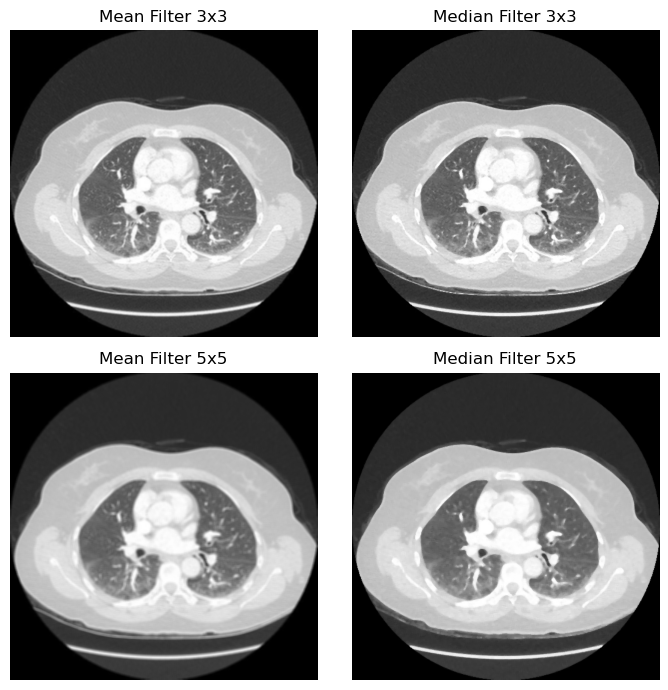

In [72]:
img = axial
median_3x3 = cv2.medianBlur(img, 3)
median_5x5 = cv2.medianBlur(img, 5)
mean_3x3 = cv2.blur(img, (3, 3))
mean_5x5 = cv2.blur(img, (5, 5))

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes[0, 1].imshow(median_3x3, cmap='gray', origin='lower')
axes[0, 1].set_title('Median Filter 3x3')
axes[1, 1].imshow(median_5x5, cmap='gray', origin='lower')
axes[1, 1].set_title('Median Filter 5x5')
axes[0, 0].imshow(mean_3x3, cmap='gray', origin='lower')
axes[0, 0].set_title('Mean Filter 3x3')
axes[1, 0].imshow(mean_5x5, cmap='gray', origin='lower')
axes[1, 0].set_title('Mean Filter 5x5')
for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()


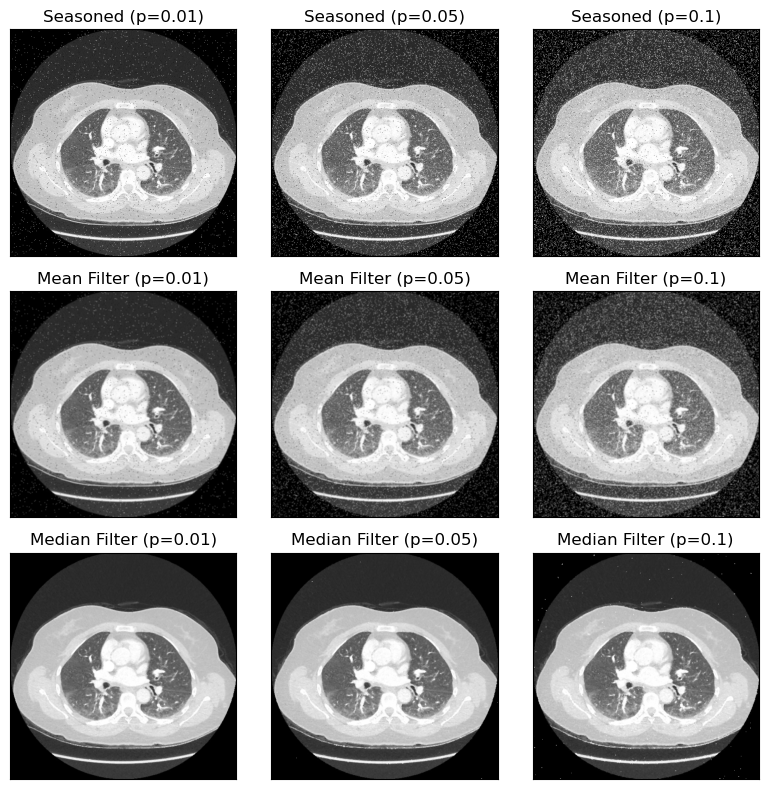

In [73]:
how_seasoned = [0.01, 0.05, 0.1]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for col, sp in enumerate(how_seasoned):
    noisy_img = add_salt_and_pepper_noise(img, sp)
    median_3x3 = cv2.medianBlur(noisy_img, 3)
    mean_3x3 = cv2.blur(noisy_img, (3, 3))
    
    axes[0, col].imshow(noisy_img, cmap='gray', origin='lower')
    axes[0, col].set_title(f"Seasoned (p={sp})")
    
    axes[1, col].imshow(mean_3x3, cmap='gray', origin='lower')
    axes[1, col].set_title(f"Mean Filter (p={sp})")

    axes[2, col].imshow(median_3x3, cmap='gray', origin='lower')
    axes[2, col].set_title(f"Median Filter (p={sp})")
    
for ax in axes.flat:
    ax.set_axis_on()
    ax.set_xticks([]) 
    ax.set_yticks([])

plt.tight_layout()
plt.show()


# III. Gauss’ Wrath

## Gaussian noise and 2D filtering

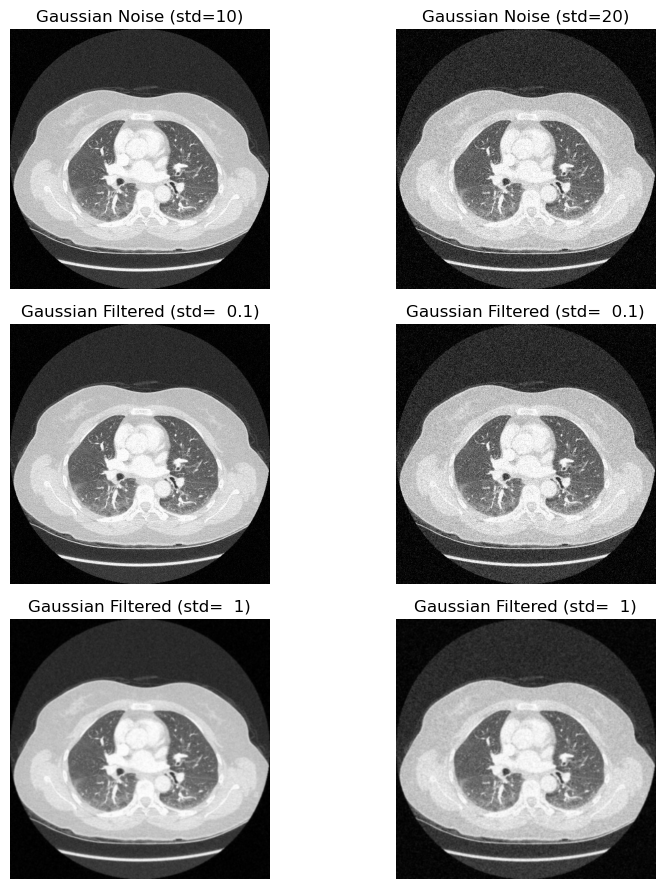

In [74]:
stddevs = [10, 20]

noisy_img_10 = add_gaussian_noise(img, 0, 10)
noisy_img_20 = add_gaussian_noise(img, 0, 20)

sigma_10 = 1/10
sigma_20 = 1

filtered_img_10_01 = ndimage.gaussian_filter(noisy_img_10, sigma=sigma_10)
filtered_img_20_01 = ndimage.gaussian_filter(noisy_img_20, sigma=sigma_10)
filtered_img_20_1 = ndimage.gaussian_filter(noisy_img_20, sigma=sigma_20)
filtered_img_10_1 = ndimage.gaussian_filter(noisy_img_10, sigma=sigma_20)

fig, axes = plt.subplots(3, 2, figsize=(9, 9))
axes[0, 0].imshow(noisy_img_10, cmap='gray', origin='lower')
axes[0, 0].set_title('Gaussian Noise (std=10)')
axes[0, 1].imshow(noisy_img_20, cmap='gray', origin='lower')
axes[0, 1].set_title('Gaussian Noise (std=20)')
axes[1, 0].imshow(filtered_img_10_01, cmap='gray', origin='lower')
axes[1, 0].set_title(f'Gaussian Filtered (std=  {sigma_10})')
axes[1, 1].imshow(filtered_img_20_01, cmap='gray', origin='lower')
axes[1, 1].set_title(f'Gaussian Filtered (std=  {sigma_10})')
axes[2, 0].imshow(filtered_img_10_1, cmap='gray', origin='lower')
axes[2, 0].set_title(f'Gaussian Filtered (std=  {sigma_20})')
axes[2, 1].imshow(filtered_img_20_1, cmap='gray', origin='lower')
axes[2, 1].set_title(f'Gaussian Filtered (std=  {sigma_20})')
for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3D Gaussian blurring

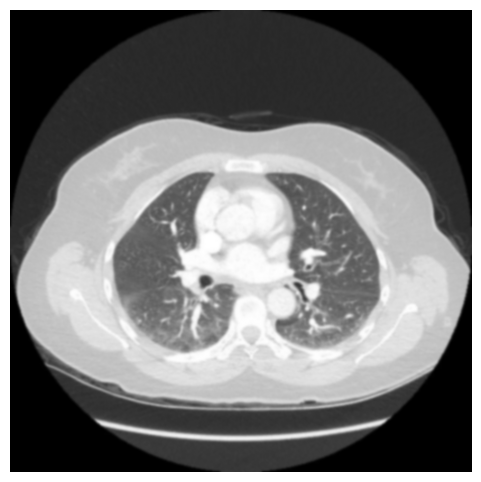

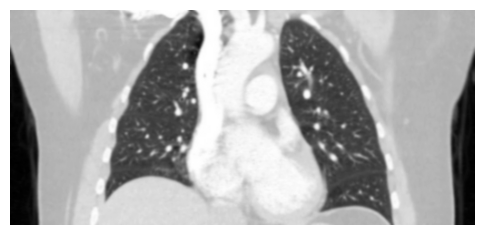

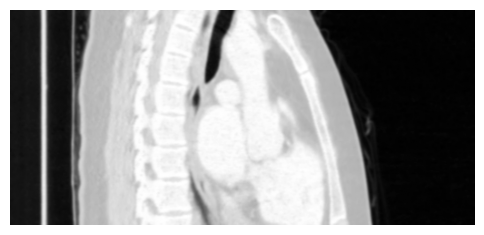

In [75]:
# Convert dx and dz to pixels
dx_mm = 2 # mm
dz_mm = 1 # mm
dx_pixels = dx_mm / pixelSpacing
dz_pixels = dz_mm / sliceSpacing

# The dx, dz are our FWHM. Compute the corresponding sigmas
sigma_x = dx_pixels / (2 * np.sqrt(2 * np.log(2)))
sigma_z = dz_pixels / (2 * np.sqrt(2 * np.log(2)))

# Normalization constant
A = 1 / ( (2 * np.pi) **(3/2) * sigma_x**2 * sigma_z)

# Apply the filter
# 'mode' handles how the edges of the scan are treated
filtered_volume = ndimage.gaussian_filter(volume, sigma=[sigma_x, sigma_x, sigma_z], mode='nearest')

filtered_axial = display_slice(filtered_volume, plane='xy', index = z_dim//2, display=False)
filtered_coronal = display_slice(filtered_volume, plane='xz', index = y_dim//2, display=False)
filtered_sagittal = display_slice(filtered_volume, plane='yz', index = x_dim // 2, display=False)

plt.figure(figsize=(6, 6))
plt.imshow(filtered_axial, cmap='gray', origin='lower')
#plt.title('Gaussian Blurred Axial Slice \n(dx=2mm, dy=2mm)')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(filtered_coronal, cmap='gray', origin='lower')
#plt.title('Gaussian Blurred Coronal Slice \n(dx=2mm, dz=1mm)')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(filtered_sagittal, cmap='gray', origin='lower')
#plt.title('Gaussian Blurred Sagittal Slice \n(dy=2mm, dz=1mm)')
plt.axis('off')
plt.show()

# IV. Foramina

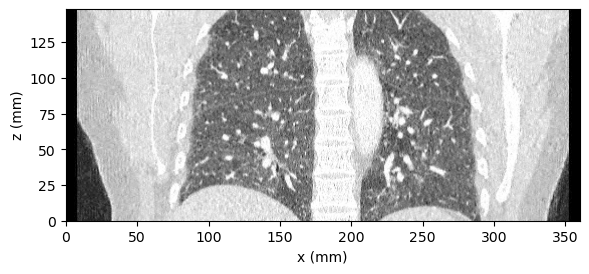

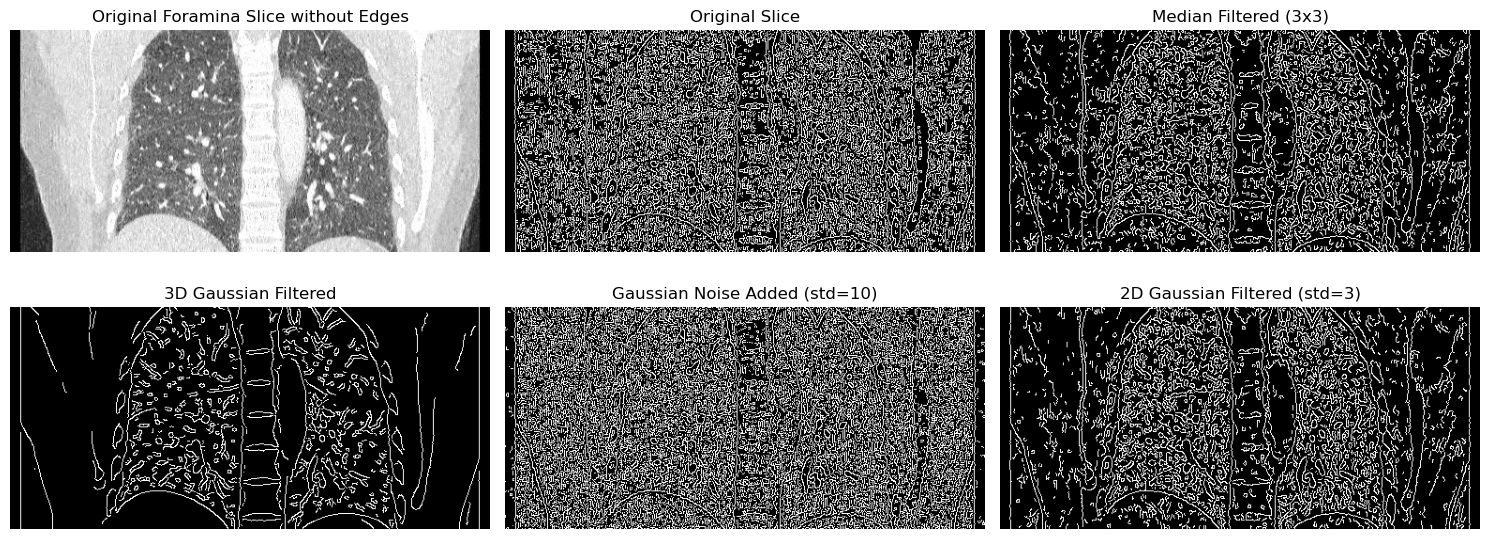

In [76]:
foramina_slice = display_slice(volume, plane='xz', index = 180)

low = 50
high = 75

median_3x3 = cv2.medianBlur(foramina_slice, 3)
gaussian_3d = display_slice(filtered_volume, plane='xz', index = 180, display=False)
gaussian_noise = add_gaussian_noise(foramina_slice, 0, 10)
gaussian_2d = cv2.GaussianBlur(foramina_slice, (3, 3), sigmaX=3, sigmaY=3)

edges_original = cv2.Canny(foramina_slice, low, high)
edges_median = cv2.Canny(median_3x3, low, high)
edges_gaussian_3d = cv2.Canny(gaussian_3d, low, high)
edges_gaussian_noise = cv2.Canny(gaussian_noise, low, high)
edges_gaussian_2d = cv2.Canny(gaussian_2d, low, high)  

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes[0, 0].imshow(foramina_slice, cmap='gray', origin='lower')
axes[0, 0].set_title('Original Foramina Slice without Edges')
axes[0, 1].imshow(edges_original, cmap='gray', origin='lower')
axes[0, 1].set_title('Original Slice')
axes[0, 2].imshow(edges_median, cmap='gray', origin='lower')
axes[0, 2].set_title('Median Filtered (3x3)')
axes[1, 0].imshow(edges_gaussian_3d, cmap='gray', origin='lower')
axes[1, 0].set_title('3D Gaussian Filtered')
axes[1, 1].imshow(edges_gaussian_noise, cmap='gray', origin='lower')
axes[1, 1].set_title('Gaussian Noise Added (std=10)')
axes[1, 2].imshow(edges_gaussian_2d, cmap='gray', origin='lower')
axes[1, 2].set_title('2D Gaussian Filtered (std=3)')
for ax in axes.flatten():
    ax.axis('off')  
plt.tight_layout()
plt.show()



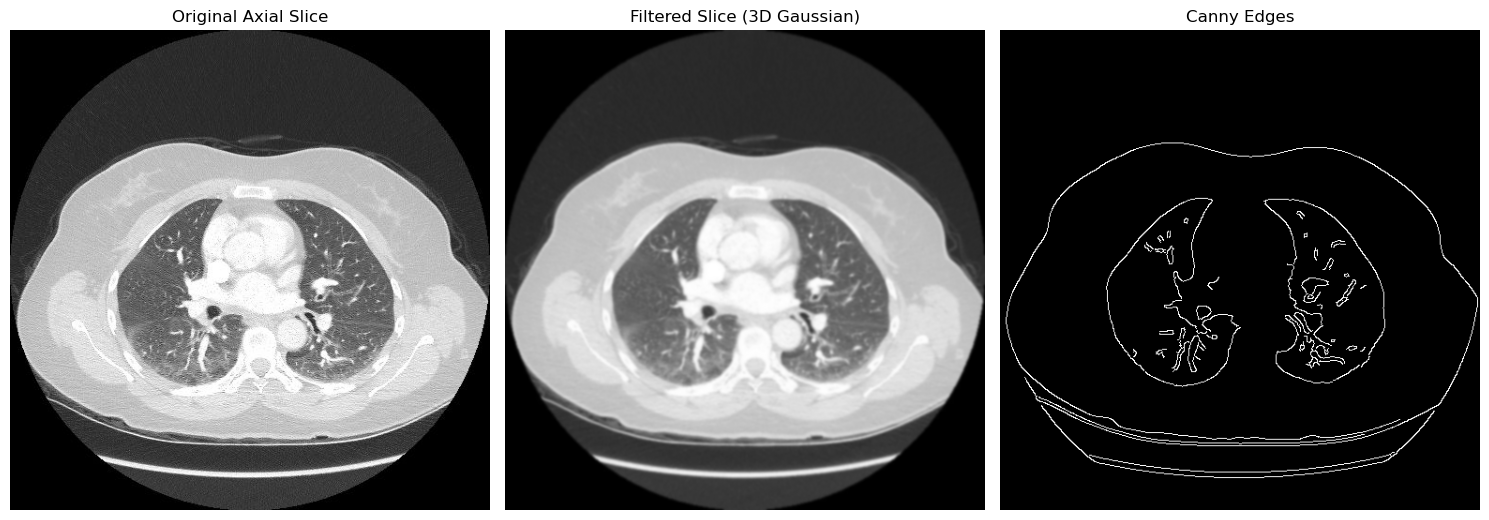

In [77]:
z_slice_gaussian_3d = display_slice(filtered_volume, plane='xy', index = z_dim//2, display=False)
z_slice_edge = cv2.Canny(z_slice_gaussian_3d, 100, 200)


fig, axes = plt.subplots(1, 3, figsize=(15, 10))
axes[0].imshow(axial, cmap='gray', origin='lower')
axes[0].set_title('Original Axial Slice')
axes[1].imshow(z_slice_gaussian_3d, cmap='gray', origin='lower')
axes[1].set_title('Filtered Slice (3D Gaussian)')
axes[2].imshow(z_slice_edge, cmap='gray', origin='lower')
axes[2].set_title('Canny Edges')
for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

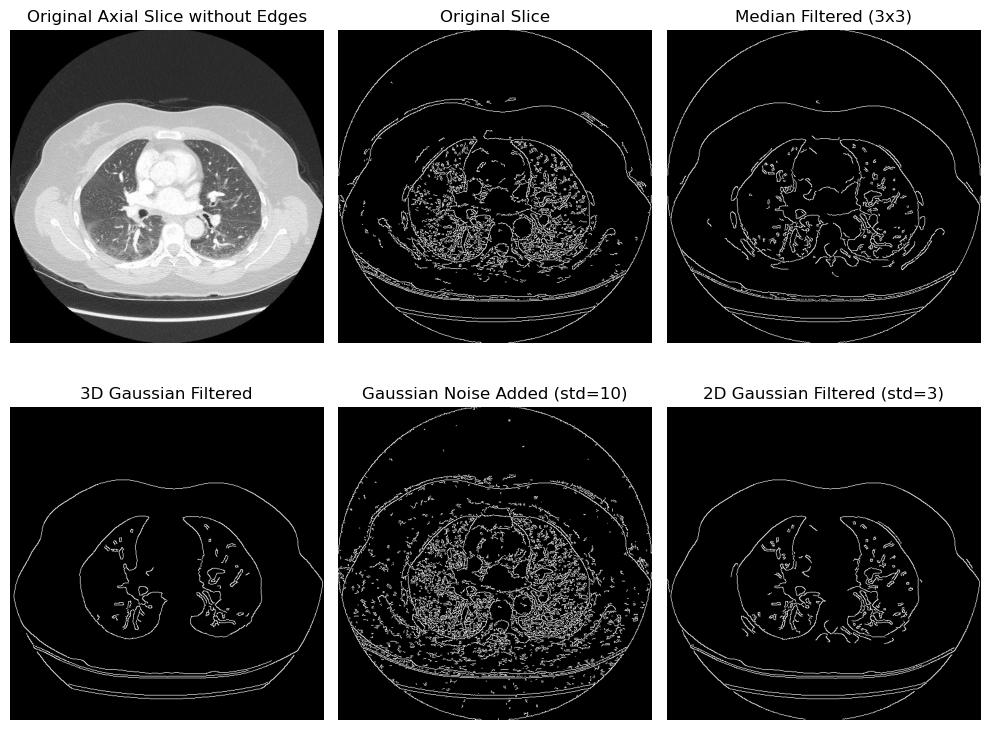

In [78]:
foramina_slice = display_slice(volume, plane='xy', index = z_dim//2, display=False)

low = 100
high = 200

median_3x3 = cv2.medianBlur(foramina_slice, 3)
gaussian_3d = display_slice(filtered_volume, plane='xy', index = z_dim//2, display=False)
gaussian_noise = add_gaussian_noise(foramina_slice, 0, 10)
gaussian_2d = cv2.GaussianBlur(foramina_slice, (3, 3), sigmaX=3, sigmaY=3)

edges_original = cv2.Canny(foramina_slice, low, high)
edges_median = cv2.Canny(median_3x3, low, high)
edges_gaussian_3d = cv2.Canny(gaussian_3d, low, high)
edges_gaussian_noise = cv2.Canny(gaussian_noise, low, high)
edges_gaussian_2d = cv2.Canny(gaussian_2d, low, high)  

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes[0, 0].imshow(foramina_slice, cmap='gray', origin='lower')
axes[0, 0].set_title('Original Axial Slice without Edges')
axes[0, 1].imshow(edges_original, cmap='gray', origin='lower')
axes[0, 1].set_title('Original Slice')
axes[0, 2].imshow(edges_median, cmap='gray', origin='lower')
axes[0, 2].set_title('Median Filtered (3x3)')
axes[1, 0].imshow(edges_gaussian_3d, cmap='gray', origin='lower')
axes[1, 0].set_title('3D Gaussian Filtered')
axes[1, 1].imshow(edges_gaussian_noise, cmap='gray', origin='lower')
axes[1, 1].set_title('Gaussian Noise Added (std=10)')
axes[1, 2].imshow(edges_gaussian_2d, cmap='gray', origin='lower')
axes[1, 2].set_title('2D Gaussian Filtered (std=3)')
for ax in axes.flatten():
    ax.axis('off')  
plt.tight_layout()
plt.show()